# GridFM on IEEE-118: an AC optimal power flow surrogate

This notebook trains a GridFM **optimal power flow** (OPF) model from scratch on a slice of the
[`gridfm/opf_small_case118_ieee`](https://huggingface.co/datasets/gridfm/opf_small_case118_ieee)
dataset, then evaluates it the way an OPF surrogate is actually judged: **dispatch accuracy**,
**cost gap**, **constraint satisfaction**, and **speed**.

AC OPF is the expensive one. Where a power flow solve takes ~4 ms on this data, an AC OPF solve
takes ~157 ms. That is what makes a surrogate worth having: OPF sits inside outer loops
(unit commitment, scenario analysis, market clearing) that call it thousands of times.

It runs end-to-end in roughly **27 minutes on Apple Silicon (MPS)**, most of it training. That is
three times the companion power-flow tutorial, for a reason worth stating up front: OPF has to
reproduce an *optimiser's* chosen dispatch rather than just solve the physics, and it needs the
extra budget to get there. At ~10 minutes (15 epochs) this config does not converge, and it is not
merely inaccurate — repeated runs of the identical config disagreed on the cost gap by ±20%, sign
included. At 50 epochs the sign is stable across runs, though the magnitude still moves by about
three percentage points. Section 3 covers the budget and section 11 the run-to-run spread; both are
explicit that "converged" here means *repeated runs agree on the conclusion*, and specifically not
that the curve is flat — the tail of the curve is itself not reproducible between runs. We also
report what the model loses at, including to a trivial DC baseline.

> Exact figures move between runs: MPS kernels are not bit-deterministic, so `seed: 0` pins the
> data split and initialisation but not the arithmetic. Treat every quoted number as approximate;
> section 11 quotes the spread across four runs of this config rather than one run's point values,
> and is explicit that each run added so far has widened at least one of those ranges.

**What you will see**

1. Real learning on generator dispatch, against a freshly-initialised model.
2. **Constraint handling** — generator and voltage box limits hold *by construction* here, which
   is an architectural property worth understanding rather than a result to celebrate.
3. **Dispatch accuracy and cost gap** vs the AC OPF optimum, with DC OPF as a reference point —
   and why DC's *negative* cost gap is a red flag rather than a win.
4. **AC feasibility**, the constraint that is not free: power-balance residual and Qg limits.
5. A large, honest **speed** advantage.

### Prerequisite: the dataset

The slice below is cut from a local copy of the full dataset. Download it once with:

```python
from huggingface_hub import snapshot_download
snapshot_download(repo_id="gridfm/opf_small_case118_ieee", repo_type="dataset",
                  local_dir="<DATA_ROOT>/opf_small_case118_ieee/raw", max_workers=16)
```

The full dataset is ~7 GB. We only read the first 25 of its `scenario_partition=*` directories,
so you can fetch just those with
`allow_patterns=["*scenario_partition=[0-9]/*", "*scenario_partition=1[0-9]/*", "*scenario_partition=2[0-4]/*"]`.
Set `DATA_ROOT` below to wherever it landed.

In [1]:
import pathlib
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import lightning.pytorch as pl
import yaml
from torch_geometric.loader import DataLoader

from gridfm_graphkit.datasets.hetero_powergrid_datamodule import LitGridHeteroDataModule
from gridfm_graphkit.io.param_handler import NestedNamespace, get_task

# --- paths (absolute, so a later chdir into the artifacts dir cannot break them) -----------
REPO = pathlib.Path.cwd().parents[1]  # examples/notebooks -> repo root
DATA_ROOT = REPO / "data"  # <- where the HF download landed
SRC = DATA_ROOT / "opf_small_case118_ieee" / "raw"  # the full dataset
# NETWORK must match `data.networks` in the config: the datamodule resolves the network name to
# <data_path>/<network>/raw, so renaming one without the other silently looks for the wrong data.
NETWORK = "nb_opf_case118"  # the slice we build below
DST = DATA_ROOT / NETWORK / "raw"
CONFIG = REPO / "examples" / "config" / "HGNS_OPF_case118_tutorial.yaml"
ARTIFACTS = (
    DATA_ROOT / "nb_out_opf"
)  # logs, normalizer stats, test CSVs (inside gitignored data/)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

N_PARTITIONS = 25  # 200 scenarios each -> 5,000

# Reference solve times, per scenario, measured by the machine that *generated* this dataset and
# recorded in its runtime_data.parquet. These are the numbers the surrogate is competing against in
# section 10. Two ratios are worth holding on to: AC OPF costs ~5x the DC approximation, and ~37x an
# AC *power flow* solve (4.3 ms in the companion PF dataset). That second one is why a surrogate is
# worth more here than on plain power flow.
AC_OPF_SOLVE_MS = 157.0
DC_OPF_SOLVE_MS = 30.0

T_START = time.time()
print("torch", torch.__version__, "| MPS available:", torch.backends.mps.is_available())
print("dataset present:", SRC.exists())

torch 2.13.0 | MPS available: True
dataset present: True


## 1. Build a small local slice

`process()` reads the *entire* raw directory into pandas regardless of `data.scenarios`, which for
the full dataset means tens of GB of peak memory. So we physically cut a smaller raw directory
first — this is a requirement, not an optimisation.

The partitions are clean: `scenario_partition=p` holds scenarios `[200p, 200p+199]`, so taking
partitions `0..24` gives contiguous scenario ids starting at 0, which is what `process()` asserts.
We write one consolidated parquet per table rather than a partitioned directory.

In [2]:
t0 = time.time()
if not (DST / "bus_data.parquet").exists():
    DST.mkdir(parents=True, exist_ok=True)
    # Three tables per scenario: bus (demand, voltage limits), gen (dispatch, cost coefficients,
    # capacity limits) and branch (topology, impedances, ratings). Upstream each is a Hive-partitioned
    # directory, so we read the first N_PARTITIONS subdirectories and concatenate into one flat file.
    for tbl in ("bus", "gen", "branch"):
        parts = [
            pd.read_parquet(SRC / f"{tbl}_data.parquet" / f"scenario_partition={p}")
            for p in range(N_PARTITIONS)
        ]
        # kind="stable" preserves the within-scenario row order the generator wrote, which is what
        # `process()` relies on when it reshapes rows into per-scenario graphs.
        df = pd.concat(parts, ignore_index=True).sort_values("scenario", kind="stable")
        df.to_parquet(DST / f"{tbl}_data.parquet", index=False)
        print(
            f"{tbl:7s} {len(df):8d} rows  scenarios {df.scenario.min()}-{df.scenario.max()}"
        )
else:
    print("slice already present, skipping")

# Keep bus and gen in memory: sections 6-8 need raw columns the model never sees -- the DC OPF
# dispatch (`p_mw_dc`) and the slack flag -- which the prediction table therefore does not carry.
bus_raw = pd.read_parquet(DST / "bus_data.parquet")
gen_raw = pd.read_parquet(DST / "gen_data.parquet")
print(
    f"\n{bus_raw.scenario.nunique()} scenarios, "
    f"{bus_raw.load_scenario_idx.nunique()} distinct load scenarios, "
    f"{sum(f.stat().st_size for f in DST.glob('*.parquet')) / 1e6:.0f} MB "
    f"({time.time() - t0:.1f}s)"
)

slice already present, skipping

5000 scenarios, 249 distinct load scenarios, 148 MB (0.1s)


The config uses `split_by_load_scenario_idx: true`, so train/val/test are split by *load scenario*
rather than by row. That prevents the same load profile appearing on both sides of the split, which
would leak. It also means you need enough distinct load scenarios for `val_ratio: 0.1` to be
non-empty — the count printed above is comfortably sufficient.

In [3]:
# NestedNamespace turns the YAML dict into a recursive argparse.Namespace, which is how the whole
# library reads config: `args.training.batch_size`, not `args["training"]["batch_size"]`.
args = NestedNamespace(**yaml.safe_load(CONFIG.read_text()))
pl.seed_everything(args.seed, workers=True)

t0 = time.time()
# The datamodule is the orchestrator. `setup("fit")` does three expensive things:
#   1. HeteroGridDatasetDisk.process() converts the raw parquet into one PyG HeteroData .pt file per
#      scenario under data/<network>/processed/ (skipped if processed_raw_files.done already exists);
#   2. it splits into train/val/test -- here by distinct load scenario, see the note above;
#   3. it *fits* the normalizer on the training split. Normalization is applied lazily inside
#      __getitem__, so the statistics have to exist before the first batch is drawn.
dm = LitGridHeteroDataModule(args, str(DATA_ROOT))
dm.setup("fit")
print(f"\ndatamodule ready in {time.time() - t0:.1f}s")
print(
    f"train {len(dm.train_datasets[0])} | val {len(dm.val_datasets[0])} | "
    f"test {len(dm.test_datasets[0])} scenarios"
)

Seed set to 0


Fitting normalizer on train set (4035 scenarios)

datamodule ready in 0.1s
train 4035 | val 472 | test 493 scenarios


A `Trainer` here **must** be given a real logger. `BaseTask.on_fit_start` writes the normalizer
statistics to `self.logger.save_dir`, so `logger=False` raises `AttributeError: 'NoneType' object
has no attribute 'save_dir'`. We use a `CSVLogger`, which also gives us the metrics to plot.

In [4]:
def make_trainer(**kw):
    """A Trainer configured the way this notebook needs it.

    `accelerator`/`devices` come from the config, so `accelerator: auto` selects MPS here.
    `enable_checkpointing=False` because we keep the trained model in memory -- nothing below
    reloads it from disk, and .ckpt files for a 20M-parameter model add up fast.
    """
    return pl.Trainer(
        accelerator=args.training.accelerator,
        devices=args.training.devices,
        logger=pl.loggers.CSVLogger(str(ARTIFACTS), name="opf"),
        enable_checkpointing=False,
        **kw,
    )


def prediction_tables(predictions):
    """Concatenate opf_task.predict_step outputs into one DataFrame per node type.

    `trainer.predict` returns a list holding whatever `predict_step` returned, one entry per batch.
    For `opf_task` that is a dict of dicts -- one sub-dict per node type -- of flat tensors, already
    de-normalised into physical units. Returns {"bus": DataFrame, "gen": DataFrame} with:

      bus (one row per bus per scenario)
        Vm_pred, Va_pred, Pg_pred, Qg_pred    the model's output
        Vm_target, Va_target, Pg_target, Qg_target    the AC OPF solver's answer
        Vm_min, Vm_max, Qg_min, Qg_max        limits, straight from the model *input*
        Pd, Qd                                real and reactive demand at the bus
        PQ, PV, REF                           one-hot bus type
        PBE                                   power-balance residual, sqrt(dP^2 + dQ^2) in MVA
        scenario, bus                         identifiers

      gen (one row per in-service generator per scenario)
        p_mw_pred, p_mw_target                predicted vs optimal dispatch, MW
        min_p_mw, max_p_mw                    capacity limits
        cp0_eur, cp1_eur_per_mw, cp2_eur_per_mw2    cost coefficients -- so section 7 can cost a
                                              dispatch without joining anything
        scenario, idx, bus                    identifiers; see `join_gen_raw` about `idx`

    Worth noticing: unlike the power-flow task, the OPF mask leaves the limit columns visible in the
    model input, which is why `Vm_min`/`Qg_max` here are usable directly rather than needing a join
    back to the raw parquet (the companion PF notebook has to do exactly that).

    Two mechanical wrinkles: Lightning nests the list one level deeper when there are multiple
    dataloaders (hence the `predictions[0]` unwrap), and some entries come back shaped (N, 1)
    rather than (N,) (hence `.ravel()`).
    """
    batches = predictions[0] if isinstance(predictions[0], list) else predictions
    out = {}
    for node_type in batches[0]:
        out[node_type] = pd.concat(
            [
                pd.DataFrame(
                    {k: np.asarray(v).ravel() for k, v in b[node_type].items()}
                )
                for b in batches
            ],
            ignore_index=True,
        )
    return out


def join_gen_raw(gen_table, columns):
    """Attach raw columns (p_mw_dc, is_slack_gen, ...) to the gen prediction table.

    The table's `idx` is the generator's position *within the graph*, produced by
    `local_index_per_graph` after `DropInactiveGen` has removed out-of-service units --
    it is not the parquet's `idx`. So we rebuild the same ordering: in-service only,
    original `idx` order, renumbered from 0 per scenario.
    """
    r = gen_raw[gen_raw.in_service == 1].sort_values(["scenario", "idx"]).copy()
    r["idx"] = r.groupby("scenario").cumcount()
    merged = gen_table.merge(
        r[["scenario", "idx", "p_mw", *columns]],
        on=["scenario", "idx"],
        suffixes=("", "_raw"),
        validate="one_to_one",
    )
    # gate the join: the table's own target must agree with the raw dispatch it was built from.
    # Without this, an off-by-one in the renumbering above would silently mis-attribute every
    # generator's dispatch and DC baseline, and the resulting metrics would look plausible.
    drift = np.abs(merged.p_mw_target - merged.p_mw).max()
    assert drift < 1e-2, f"gen join misaligned: max |p_mw_target - raw p_mw| = {drift}"
    return merged


print("helpers defined")

helpers defined


## 2. The untrained baseline

Before training, record what a freshly-initialised model of the same architecture predicts. Every
later accuracy claim is measured against this, so "the model learned something" is a comparison
rather than an assertion.

In [5]:
# get_task resolves `task.task_name` ("OptimalPowerFlow") through the TASK registry and builds the
# LightningModule: model + loss + metrics, all named by strings in the YAML. The normalizers are
# handed in because the task de-normalises predictions before computing physical-unit metrics.
# A fresh call means freshly initialised weights, so this is an independent instance -- training
# `task` in section 3 does not touch it.
untrained = get_task(args, dm.data_normalizers)
print(f"{sum(p.numel() for p in untrained.model.parameters()) / 1e6:.1f} M parameters")

pred_untrained = prediction_tables(
    make_trainer(enable_progress_bar=False).predict(untrained, datamodule=dm)
)
g0 = pred_untrained["gen"]
# Dispatch MAE over every in-service generator in every held-out scenario. Printed next to the mean
# |Pg| because an MAE in MW means nothing without the scale it is measured against.
mae_untrained = (g0.p_mw_pred - g0.p_mw_target).abs().mean()
print(
    f"untrained dispatch MAE: {mae_untrained:.2f} MW "
    f"(mean |Pg| = {g0.p_mw_target.abs().mean():.2f} MW)"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


20.1 M parameters
Setup already done for stage=TrainerFn.PREDICTING, skipping...


/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:378: You have overridden `transfer_batch_to_device` in `LightningModule` but have passed in a `LightningDataModule`. It will use the implementation from `LightningModule` instance.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors

untrained dispatch MAE: 43.85 MW (mean |Pg| = 81.70 MW)


## 3. Train

50 epochs at batch 64. The loss is a weighted mix declared in the config: a layered physics
residual, masked MSE on generation, masked MSE on bus quantities, and a Qg violation penalty.

The tutorial config differs from the reference `HGNS_OPF_datakit_case118.yaml` **only in budget
knobs** — network, scenario count, epochs, workers, devices. The model and the loss weights are
untouched, so what you measure below is the reference recipe on a small budget rather than a
separately tuned one. (Up-weighting `MaskedGenMSE` does improve dispatch, but at the cost of
noticeably worse AC feasibility — see the config header for the measured trade-off.)

**Why 50 epochs and not 15.** 63 optimizer steps per epoch × 15 epochs is 945 steps for a 20.1 M
parameter model, and that is not enough to land anywhere stable: repeated runs of the identical
config produced cost gaps of +14%, −18% and +23% — disagreeing not only in magnitude but in *sign*,
which is the difference between "our dispatch is expensive" and "our dispatch is impossibly cheap".
At 50 epochs four runs came out at 8.0%, 9.0%, 10.8% and 11.3%: still a three-point spread, but all
with the same sign, so the qualitative reading survives a re-run. The extra ~18 minutes buys that
much and no more — see section 11 for what it means for the numbers you are about to measure.

**What "converged enough" means here, and what it does not.** It is a claim about *repeated runs
agreeing*, not about the shape of the curve below. That distinction is not pedantic: across runs of
this identical config, the last 10 epochs have variously improved validation loss by ~10% and drifted
~6% back off their best. The curve's tail is not even reproducible in sign, let alone a reliable
convergence signal, so reading one run's slope would tell you close to nothing. Whichever way this
run's trend comes out, the cell below reports it and then says so.

In [6]:
# Re-seed here. Building the untrained baseline above drew from the global RNG, so without
# this the trained model's initialisation would depend on whether that cell was run --
# and OPF at this budget is sensitive enough to initialisation for that to matter.
pl.seed_everything(args.seed, workers=True)

task = get_task(args, dm.data_normalizers)
trainer = make_trainer(max_epochs=args.training.epochs, log_every_n_steps=50)

t0 = time.time()
trainer.fit(task, datamodule=dm)
t_train = time.time() - t0
print(
    f"\ntrained {args.training.epochs} epochs in {t_train:.0f}s "
    f"({t_train / args.training.epochs:.1f}s/epoch)"
)

Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Setup already done for stage=TrainerFn.FITTING, skipping...


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GNS_heterogeneous │ 20.1 M │ train │     0 │
│ 1 │ loss_fn │ MixedLoss         │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 20.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 M                                                                                               
Total estimated model params size (MB): 80.277                                                                     
Modules in train mode: 355                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/da
ta_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

creating train dataloader for rank  not distributed

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/da
ta_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=50` reached.



trained 50 epochs in 1545s (30.9s/epoch)


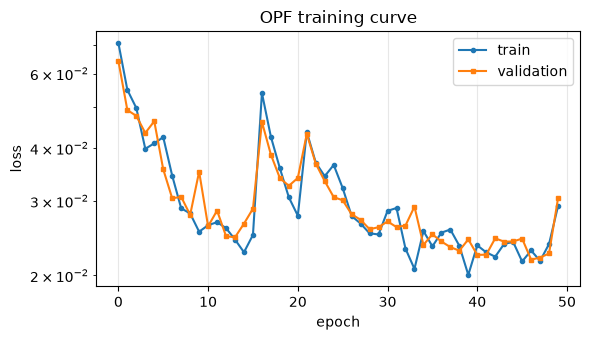

validation loss 0.0643 -> 0.0304 (best 0.0218)
mean over the last 10 epochs 0.0239 vs the 10 before 0.0251
remaining improvement per 10 epochs: +5.1%
total fall over the run: 2.1x


In [10]:
metrics = pd.read_csv(pathlib.Path(trainer.logger.log_dir) / "metrics.csv")
# note the capitalisation: the task logs "Training Loss" but "Validation loss"
val = (
    metrics.dropna(subset=["Validation loss"])
    .groupby("epoch")["Validation loss"]
    .last()
)
train_loss = (
    metrics.dropna(subset=["Training Loss"]).groupby("epoch")["Training Loss"].last()
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(train_loss.index, train_loss.values, label="train", marker="o", ms=3)
ax.plot(val.index, val.values, label="validation", marker="s", ms=3)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.set_title("OPF training curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# The curve is noisy epoch to epoch, so measure the trend over 10-epoch windows: a
# last-vs-previous-epoch comparison on a plateau this ragged mostly answers noise.
prev, last = val.iloc[-20:-10].mean(), val.iloc[-10:].mean()
trend = 100 * (prev - last) / prev
print(f"validation loss {val.iloc[0]:.4f} -> {val.iloc[-1]:.4f} (best {val.min():.4f})")
print(f"mean over the last 10 epochs {last:.4f} vs the 10 before {prev:.4f}")
print(f"remaining improvement per 10 epochs: {trend:+.1f}%")
print(f"total fall over the run: {val.iloc[0] / val.iloc[-1]:.1f}x")



## 4. The task's own test metrics

`trainer.test` runs the OPF task's metric suite. It logs with `logger=False`, so the returned dict
is empty and the numbers are printed and written to CSV under the logger directory instead.

In [11]:
# Runs the OPF task's own metric suite over the test split. The returned dict is empty by design --
# the task logs with logger=False -- so read the numbers from the printed table, or from the CSVs the
# task writes under <logger save_dir>/test/. "Mean optimality gap (%)" there is the same quantity
# section 7 recomputes by hand, which is how we gate our cost arithmetic against the library's.
trainer.test(task, datamodule=dm)

Output()

Setup already done for stage=TrainerFn.TESTING, skipping...


/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

[{}]

In [12]:
# `gen_t` and `bus_t` are what the whole second half of the notebook works from: the trained model's
# predictions on the held-out split, with ground truth alongside. Built with a separate Trainer from
# the one that fitted, purely to keep the progress bar quiet.
pred = prediction_tables(
    make_trainer(enable_progress_bar=False).predict(task, datamodule=dm)
)
gen_t, bus_t = pred["gen"], pred["bus"]
print(
    f"gen rows {len(gen_t)} | bus rows {len(bus_t)} | "
    f"test scenarios {gen_t.scenario.nunique()}"
)

# Exactly the metric computed for the untrained baseline in section 2, so the ratio is
# apples-to-apples: same split, same generators, same definition.
mae_trained = (gen_t.p_mw_pred - gen_t.p_mw_target).abs().mean()
print(f"\n{'':22s}{'untrained':>12s}{'trained':>12s}{'improvement':>14s}")
print(
    f"{'dispatch MAE (MW)':22s}{mae_untrained:12.2f}{mae_trained:12.2f}"
    f"{mae_untrained / mae_trained:13.1f}x"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Setup already done for stage=TrainerFn.PREDICTING, skipping...
gen rows 26043 | bus rows 58174 | test scenarios 493

                         untrained     trained   improvement
dispatch MAE (MW)            43.85       19.14          2.3x


## 5. Constraint handling: what is free and what is not

Read the model before trusting the metrics. For `OptimalPowerFlow`, `GNS_heterogeneous` applies
`bound_with_sigmoid` at **every layer** to both generator active power and bus voltage magnitude:

```python
gen_temp[:, PG_OUT_GEN] = bound_with_sigmoid(gen_temp[:, PG_OUT_GEN],
                                             x_dict["gen"][:, MIN_PG], x_dict["gen"][:, MAX_PG])
bus_temp[:, VM_OUT]     = bound_with_sigmoid(bus_temp[:, VM_OUT],
                                             x_dict["bus"][:, MIN_VM_H], x_dict["bus"][:, MAX_VM_H])
```

So `min_p_mw <= Pg <= max_p_mw` and `min_vm_pu <= Vm <= max_vm_pu` are satisfied **by construction**.
Reporting "100% of box constraints respected" would therefore be measuring the architecture, not the
training. We verify it as a sanity check and then move on to the constraints that are *not* free.

In [13]:
# `is_slack_gen` and `p_mw_dc` (the DC OPF dispatch) are not model inputs, so they come from the raw
# parquet. Everything else below is already in the prediction table.
g = join_gen_raw(gen_t, ["max_p_mw", "min_p_mw", "is_slack_gen", "p_mw_dc"])


def box_report(label, pg, lo, hi):
    """Report how far a dispatch falls outside [lo, hi], elementwise.

    The double `maximum` is the standard one-sided violation: `lo - pg` is positive only when pg is
    below the floor, `pg - hi` only when above the ceiling, and the outer max against 0 zeroes out
    every generator that is comfortably inside its range. So `over` is 0 where the limit holds and
    the magnitude of the breach where it does not -- which averages and maxes meaningfully, unlike
    a signed difference.
    """
    over = np.maximum(0.0, np.maximum(lo - pg, pg - hi))
    print(
        f"  {label:10s} max violation {over.max():10.2e} MW   "
        f"rows outside bounds by >1e-3 MW: {int((over > 1e-3).sum())}"
    )


# Three dispatches against the same limits. AC OPF is the optimiser's own answer, so it respects them
# by definition -- it is here as a control, to show the check itself works.
print("generator active-power box limits:")
box_report("GridFM", g.p_mw_pred.values, g.min_p_mw.values, g.max_p_mw.values)
box_report("AC OPF", g.p_mw_target.values, g.min_p_mw.values, g.max_p_mw.values)
box_report("DC OPF", g.p_mw_dc.values, g.min_p_mw.values, g.max_p_mw.values)

vm_over = np.maximum(
    0.0, np.maximum(bus_t.Vm_min - bus_t.Vm_pred, bus_t.Vm_pred - bus_t.Vm_max)
)
print(f"\nbus voltage box limits: GridFM max violation {vm_over.max():.2e} p.u.")
# Assert rather than report: this is not a result about training, it is a check that the sigmoid
# bounding described above is actually wired up. If it ever fails, the architecture changed and the
# framing of this whole section is wrong -- better to stop than to quietly print a violation.
assert vm_over.max() < 1e-4 and (g.p_mw_pred <= g.max_p_mw + 1e-3).all(), (
    "sigmoid bounding should make box constraints exact"
)
print("box constraints hold by construction, as expected")

generator active-power box limits:
  GridFM     max violation   0.00e+00 MW   rows outside bounds by >1e-3 MW: 0
  AC OPF     max violation   3.81e-06 MW   rows outside bounds by >1e-3 MW: 0
  DC OPF     max violation   9.79e-06 MW   rows outside bounds by >1e-3 MW: 0

bus voltage box limits: GridFM max violation 0.00e+00 p.u.
box constraints hold by construction, as expected


## 6. Dispatch accuracy

How close is the predicted dispatch to the AC OPF optimum, per generator? We break the slack
generator out separately: it absorbs whatever the rest of the system does not supply, including
network losses, so it is both the largest and the hardest quantity to predict.

26043 in-service generators over 493 held-out scenarios

  group            n  mean |Pg|  GridFM MAE     RMSE   DC MAE  DC RMSE
  all          26043       81.7       19.14    62.10     7.36    32.50
  slack          493      601.6      219.08   286.27    72.05   105.85
  non-slack    25550       71.7       15.28    48.47     6.11    29.33


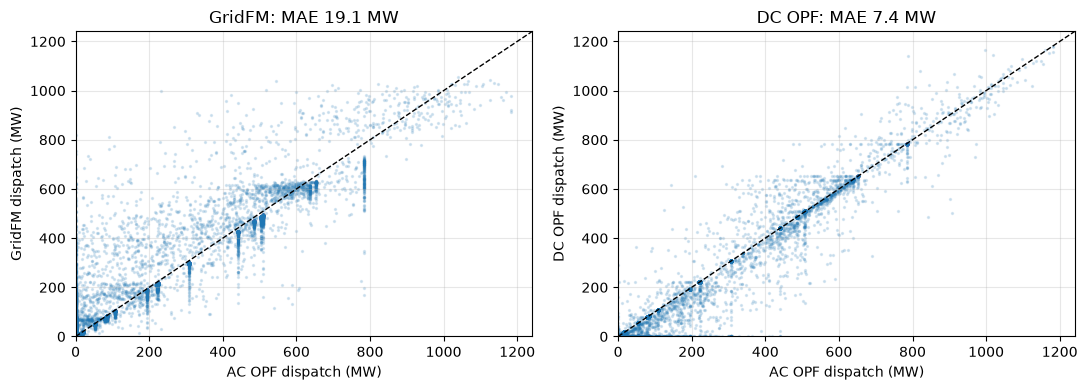

In [15]:
# Signed errors, kept signed: section 7 needs to know whether the dispatch is systematically high or
# low, which an absolute error throws away. `err_dc` gives the DC baseline the identical treatment.
g["err"] = g.p_mw_pred - g.p_mw_target
g["err_dc"] = g.p_mw_dc - g.p_mw_target

print(
    f"{len(g)} in-service generators over {g.scenario.nunique()} held-out scenarios\n"
)
print(
    f"  {'group':11s}{'n':>7s}{'mean |Pg|':>11s}"
    f"{'GridFM MAE':>12s}{'RMSE':>9s}{'DC MAE':>9s}{'DC RMSE':>9s}"
)
# Split out the slack generator because it is a different kind of quantity, not just a bigger one:
# it takes up whatever the other units do not supply, network losses included, so its dispatch is a
# residual of everything else in the network. RMSE next to MAE because RMSE punishes the occasional
# large miss -- if the two diverge sharply, a few scenarios dominate the error.
for label, s in (
    ("all", g),
    ("slack", g[g.is_slack_gen == 1]),
    ("non-slack", g[g.is_slack_gen == 0]),
):
    print(
        f"  {label:11s}{len(s):7d}{s.p_mw_target.abs().mean():11.1f}"
        f"{s.err.abs().mean():12.2f}{np.sqrt((s.err**2).mean()):9.2f}"
        f"{s.err_dc.abs().mean():9.2f}{np.sqrt((s.err_dc**2).mean()):9.2f}"
    )

# Predicted vs optimal, one point per generator per scenario. The dashed line is y=x, so vertical
# spread about it is the error; alpha and rasterization keep ~25k overlapping points readable.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (label, col) in zip(axes, (("GridFM", "p_mw_pred"), ("DC OPF", "p_mw_dc"))):
    ax.scatter(g.p_mw_target, g[col], s=2, alpha=0.15, rasterized=True)
    lim = [0, g.p_mw_target.max() * 1.05]
    ax.plot(lim, lim, "k--", lw=1)
    # Identical axes on both panels, so the two baselines are visually comparable.
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("AC OPF dispatch (MW)")
    ax.set_ylabel(f"{label} dispatch (MW)")
    ax.set_title(f"{label}: MAE {(g[col] - g.p_mw_target).abs().mean():.1f} MW")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cost gap

The economic metric. Generation cost is `cp0 + cp1*Pg + cp2*Pg^2`; in this dataset `cp0` and `cp2`
are identically zero, so cost reduces to the linear `sum(cp1 * Pg)` — we still evaluate the full
polynomial so the cell stays correct on data where they are not.

Read the sign carefully. A *positive* gap means the dispatch is more expensive than optimal, which
is the honest failure mode. A *negative* gap does not mean beating the optimum — it means solving a
different, easier problem. DC OPF ignores network losses, so it under-procures generation and lands
below the true AC cost in essentially every scenario. Cheap on paper, undeliverable in practice.

mean AC OPF cost: 104,303 EUR/h

                mean   median       p5      p95  mean |gap|  below opt
  GridFM      +17.76   +17.15    +0.57   +38.93       18.47       4.9%
  DC OPF       -4.88    -4.47    -7.97    -3.59        4.88     100.0%

mean absolute gap 18.47% -- compare 'Mean optimality gap (%)' in the test table above (same definition)


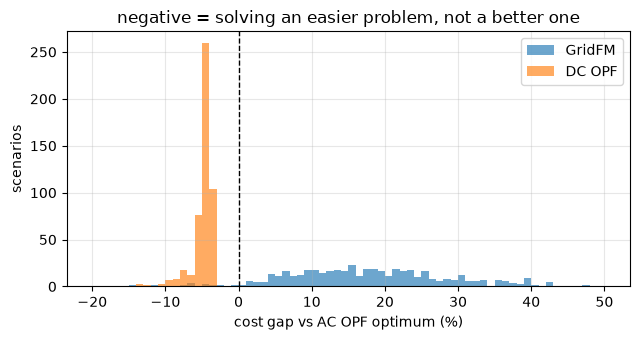

In [16]:
def total_cost(pg, x):
    """System-wide generation cost, EUR/h, for a dispatch vector `pg`.

    The coefficients ride along in the prediction table (see `prediction_tables`), so `x` is just
    the rows being costed and no join is needed. Summed over generators, giving one cost per
    scenario when applied per group.
    """
    return (x.cp0_eur + x.cp1_eur_per_mw * pg + x.cp2_eur_per_mw2 * pg**2).sum()


# One row per scenario, three columns: what the optimiser's dispatch costs, what ours costs, what
# DC's costs -- all evaluated with the *same* cost function, so the comparison is only about the
# dispatches. include_groups=False silences a pandas deprecation about passing the grouping column
# into the applied function.
cost = g.groupby("scenario").apply(
    lambda x: pd.Series(
        {
            "ac": total_cost(x.p_mw_target, x),
            "gfm": total_cost(x.p_mw_pred, x),
            "dc": total_cost(x.p_mw_dc, x),
        }
    ),
    include_groups=False,
)
print(f"mean AC OPF cost: {cost.ac.mean():,.0f} EUR/h\n")
print(
    f"  {'':9s}{'mean':>9s}{'median':>9s}{'p5':>9s}{'p95':>9s}{'mean |gap|':>12s}{'below opt':>11s}"
)
# Both a signed mean and a mean absolute gap, because they answer different questions. The signed
# mean can look small through cancellation -- expensive scenarios offsetting cheap ones -- while the
# absolute mean measures how wrong a typical scenario is. The p5/p95 columns and the "below opt"
# fraction show which of the two is happening.
for key, label in (("gfm", "GridFM"), ("dc", "DC OPF")):
    gap = 100 * (cost[key] - cost.ac) / cost.ac
    print(
        f"  {label:9s}{gap.mean():+9.2f}{np.median(gap):+9.2f}"
        f"{np.percentile(gap, 5):+9.2f}{np.percentile(gap, 95):+9.2f}"
        f"{gap.abs().mean():12.2f}{100 * (gap < 0).mean():10.1f}%"
    )

# gate: our mean absolute gap must reproduce the task's own "Mean optimality gap (%)" metric. Two
# independent implementations of the same definition -- if they disagree, one of them is wrong and
# every cost number in this notebook is suspect.
gap_gfm = 100 * (cost.gfm - cost.ac) / cost.ac
print(
    f"\nmean absolute gap {gap_gfm.abs().mean():.2f}% "
    f"-- compare 'Mean optimality gap (%)' in the test table above (same definition)"
)

# Shared bins so the two histograms are directly comparable, and a line at zero because the sign is
# the whole point: GridFM's mass sits to the right of it (too expensive), DC's to the left.
fig, ax = plt.subplots(figsize=(6.5, 3.5))
bins = np.linspace(-20, 50, 71)
ax.hist(gap_gfm, bins=bins, alpha=0.65, label="GridFM")
ax.hist(100 * (cost.dc - cost.ac) / cost.ac, bins=bins, alpha=0.65, label="DC OPF")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("cost gap vs AC OPF optimum (%)")
ax.set_ylabel("scenarios")
ax.set_title("negative = solving an easier problem, not a better one")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Where the error lives

Section 6 showed the slack generator carrying by far the largest *per-unit* error. But per-unit error
is not what the cost gap integrates, so before concluding "fix the slack" we should check. This cell
substitutes ground truth for one group of generators at a time and re-costs — a counterfactual, not a
better model, and the point is to decide what to fix next rather than guess.

Watch the two rows against each other: the slack is one generator out of ~53, so if the gap were
mostly its fault, making it exact would collapse the gap on its own.

In [17]:
def gap_with_truth_for(mask):
    """Cost gap when generators selected by `mask` are predicted perfectly.

    `np.where` splices two dispatch vectors together: ground truth wherever `mask` is True, the
    model's own prediction everywhere else. Re-costing that hybrid answers "how much of the gap
    would disappear if this group were solved?" -- attribution by substitution, which needs no
    retraining and no assumption that the error decomposes linearly.
    """
    pg = np.where(mask, g.p_mw_target, g.p_mw_pred)
    h = g.assign(pg=pg)
    c = h.groupby("scenario").apply(
        lambda x: pd.Series(
            {"ac": total_cost(x.p_mw_target, x), "mix": total_cost(x.pg, x)}
        ),
        include_groups=False,
    )
    return (100 * (c.mix - c.ac) / c.ac).abs().mean()


is_slack = (g.is_slack_gen == 1).values
print("mean absolute cost gap, substituting ground truth for some generators:\n")
# An all-False mask substitutes nothing, so this row must reproduce section 7's headline gap. It is
# here as a control: if it does not match, the splicing above is misaligned.
print(
    f"  {'as predicted (nothing substituted)':45s}{gap_with_truth_for(np.zeros(len(g), bool)):7.2f}%"
)
# The two rows that matter. They are deliberately not required to sum to the total -- costs are not
# separable that way -- so read each as "the gap that survives if this group were free".
print(f"  {'slack generator exact':45s}{gap_with_truth_for(is_slack):7.2f}%")
print(f"  {'all non-slack generators exact':45s}{gap_with_truth_for(~is_slack):7.2f}%")
# The share of dispatched MW is the number that makes the result interpretable: one generator
# carrying ~14% of the energy cannot account for most of a cost gap, however large its own error.
print(
    f"\n{is_slack.sum()} slack rows out of {len(g)} "
    f"({100 * is_slack.mean():.1f}% of generators, "
    f"{100 * g[is_slack].p_mw_target.sum() / g.p_mw_target.sum():.1f}% of dispatched MW)"
)

mean absolute cost gap, substituting ground truth for some generators:

  as predicted (nothing substituted)             18.47%
  slack generator exact                          14.00%
  all non-slack generators exact                  6.77%

493 slack rows out of 26043 (1.9% of generators, 13.9% of dispatched MW)


## 9. AC feasibility — the constraint that is not free

Box limits came free from the sigmoid. Kirchhoff's laws did not. Two checks:

- **Power-balance residual** (`PBE` in the prediction table): the mismatch in MVA at each bus
  between injected and withdrawn power. A truly feasible AC state has zero residual.
- **Reactive limits** on generator buses: `Qg` is *not* sigmoid-bounded, so `Qg_min <= Qg <= Qg_max`
  is a genuine, learnable constraint that the model can and does violate.

power-balance residual (MVA per bus): mean 10.311  median 6.470  p95 28.275  max 724.5

Qg limits on 26043 generator buses: 25.1% violated, mean violation 5.87 MVar, max 149.5 MVar


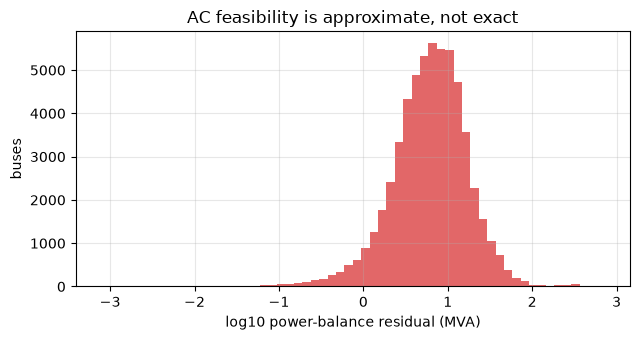

In [18]:
# PBE is computed inside predict_step, not here: it is sqrt(dP^2 + dQ^2) in MVA at each bus, where
# dP/dQ are the mismatch between the power flowing in over the branches and the power injected or
# withdrawn locally. Zero at every bus means the predicted voltages are a genuine AC solution. The
# median next to the mean because the distribution has a long right tail -- a few badly-solved buses
# would drag the mean well above what a typical bus looks like.
print(
    f"power-balance residual (MVA per bus): mean {bus_t.PBE.mean():.3f}  "
    f"median {bus_t.PBE.median():.3f}  p95 {bus_t.PBE.quantile(0.95):.3f}  "
    f"max {bus_t.PBE.max():.1f}"
)

# Qg limits only exist where there is a generator, i.e. at PV and REF buses. At PQ buses the limits
# are both zero and there is nothing to violate, so including them would dilute the percentage.
gen_bus = bus_t[(bus_t.PV == 1) | (bus_t.REF == 1)]
qv = np.maximum(
    0.0, np.maximum(gen_bus.Qg_min - gen_bus.Qg_pred, gen_bus.Qg_pred - gen_bus.Qg_max)
)
# Unlike Pg and Vm, Qg is never passed through bound_with_sigmoid, so this is the one box-type
# constraint the model actually has to *learn*. That is why it is reported as a rate, not asserted.
print(
    f"\nQg limits on {len(gen_bus)} generator buses: "
    f"{100 * (qv > 1e-6).mean():.1f}% violated, mean violation {qv.mean():.2f} MVar, "
    f"max {qv.max():.1f} MVar"
)

# log10 because the residuals span several orders of magnitude; a linear axis would put every bus in
# the first bin. Clipping at 1e-4 keeps near-zero buses on the plot instead of at -inf.
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(np.log10(np.clip(bus_t.PBE, 1e-4, None)), bins=60, color="tab:red", alpha=0.7)
ax.set_xlabel("log10 power-balance residual (MVA)")
ax.set_ylabel("buses")
ax.set_title("AC feasibility is approximate, not exact")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Speed

The reason to build a surrogate. Timing has to be done carefully: `trainer.predict` includes
dataloading, normalizer inversion and DataFrame assembly, which are not part of what an OPF solver
does. We time the **pure forward pass** on batches already resident on the device, then state
plainly what is excluded.

The solver reference (157 ms AC, 30 ms DC per scenario) is measured on the machine that *generated*
the dataset, not this one, so the ratio is indicative rather than a controlled benchmark.

In [19]:
# Lightning may have left the model on CPU after predict, so place it explicitly.
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
task.model.to(device).eval()

# Pre-move the batches: dataloading and host->device transfer are real production costs, but they are
# not what an OPF solver does, so timing them would compare two different things. Four batches is
# enough for a stable average and keeps the resident memory small.
loader = DataLoader(dm.test_datasets[0], batch_size=64, shuffle=False)
resident = [b.to(device) for b in list(loader)[:4]]
n_scenarios = sum(int(b["scenario_id"].numel()) for b in resident)

with torch.no_grad():
    for b in resident:  # warm up: the first calls pay MPS kernel compilation
        task.model(b)
    # MPS queues work asynchronously, so without synchronize() we would time the enqueue rather than
    # the compute -- an easy way to "measure" an impossibly fast model.
    if device.type == "mps":
        torch.mps.synchronize()
    t0 = time.time()
    for _ in range(
        5
    ):  # 5 repeats over the same batches, to average out scheduling noise
        for b in resident:
            task.model(b)
    if device.type == "mps":
        torch.mps.synchronize()
    ms = (time.time() - t0) / (5 * n_scenarios) * 1e3

print(
    f"GridFM forward pass: {ms:.2f} ms/scenario on {device.type} "
    f"(batch 64, {n_scenarios} scenarios x 5 repeats)"
)
print(
    f"AC OPF solver:       {AC_OPF_SOLVE_MS:.0f} ms/scenario   -> {AC_OPF_SOLVE_MS / ms:.0f}x speedup"
)
print(
    f"DC OPF solver:       {DC_OPF_SOLVE_MS:.0f} ms/scenario   -> {DC_OPF_SOLVE_MS / ms:.0f}x speedup"
)
print(
    "\nexcluded from the GridFM figure: dataloading, normalizer inversion, table assembly."
)
print(
    "solver timings come from the dataset's runtime_data.parquet (different machine)."
)

GridFM forward pass: 1.96 ms/scenario on mps (batch 64, 256 scenarios x 5 repeats)
AC OPF solver:       157 ms/scenario   -> 80x speedup
DC OPF solver:       30 ms/scenario   -> 15x speedup

excluded from the GridFM figure: dataloading, normalizer inversion, table assembly.
solver timings come from the dataset's runtime_data.parquet (different machine).


In [20]:
# Wall-clock accounting, so you can see how the ~27 minutes divides. T_START was set in the first
# cell, so "total notebook" includes slicing, process(), training, three predict passes and every
# analysis cell above -- run the cells out of order and this number stops meaning anything.
print(f"training       {t_train:6.0f}s")
print(f"total notebook {time.time() - T_START:6.0f}s")

training         1545s
total notebook   3125s


## 11. Summary

MPS kernels are not bit-deterministic, so `seed: 0` pins the data split and the initialisation but
not the arithmetic, and every number below moves between runs. **The ranges are the spread across
four runs of this config** — three of this notebook and one through the CLI
(`gridfm_graphkit train --config examples/config/HGNS_OPF_case118_tutorial.yaml`), which trains the
identical config and reports the same metrics. Rows the CLI run does not produce are marked ³ and
span the three notebook runs only. DC OPF rows carry no superscript: they involve no model and are
identical every run.

| Quantity | Result |
|---|---|
| Dispatch MAE ³ / RMSE | 15.3–16.7 ³ / 49.3–53.5 MW, against a mean \|Pg\| of 81.7 MW |
| — slack generator ³ | MAE 174–185 MW on a mean of 602 MW |
| — non-slack generators ³ | MAE 12.3–13.5 MW on a mean of 71.7 MW |
| — untrained baseline ³ | MAE 43.9 MW, i.e. a 2.6–2.9× improvement |
| Mean absolute cost gap | 8.0–11.3%, positive-signed in all four runs |
| — with slack exact ³ | 8.7–9.6% — one unit, 13.9% of dispatched MW |
| — with all non-slack exact ³ | 5.0–5.5% — the aggregate of many small errors dominates |
| DC OPF cost gap, for reference | −4.9%, below the optimum in 100% of scenarios |
| DC OPF dispatch MAE / RMSE | 7.4 / 32.5 MW — better than GridFM at this budget |
| Generator & voltage box limits | exact, by construction (sigmoid bounding) |
| Power-balance residual ³ | 5.2–6.1 MVA/bus mean, 12.5–14.4 p95 |
| Qg limit violations | 19–24% of generator buses ³, mean violation 2.6–5.2 MVar |
| Bus RMSE | Vm 0.020–0.025 p.u., Va 0.130–0.138 rad |
| Speed ³ | 81–82× vs AC OPF (1.91–1.95 ms vs 157 ms per scenario) |
| Total runtime ³ | 26–28 minutes on an M-series laptop |

**How reproducible this actually is.** Four runs of this config gave mean absolute cost gaps of
8.0%, 9.0%, 10.8% and 11.3% — a spread of about three percentage points, all of the same sign. That
is a real improvement on 15 epochs, where the same measurement came out +14%, −18% and +23%: there
the *sign* moved, which is the difference between "our dispatch is expensive" and "our dispatch is
impossibly cheap", and no qualitative reading survived. Here every run says the same thing, and the
number to quote is *roughly 10% above the economic optimum*.

It is worth recording how those ranges were arrived at, because the trap is a subtle one. The first
two runs landed half a point apart on cost gap, which looked like tight reproducibility. The third,
at 8.0%, showed that was n=2 luck. The fourth then pushed four *other* rows of this table outside the
bounds the first three had established — slack MAE, both substitution rows, and the mean Qg violation,
which nearly doubled. Each additional run widened something. Practically: do not read a one-point
cost-gap difference between two configurations as a result at this budget, and treat every range here
as a lower bound on the true spread rather than a measured interval.

The one number that does *not* settle down is the tail of the training curve. Depending on the run,
the last 10 epochs improve validation loss by ~10% or drift ~6% back off their best. So "is the curve
still falling?" is not a usable convergence test here — which is why this section reports run-to-run
agreement instead, and why the section 3 discussion insists on the distinction.

**What to take away.** The architecture makes generator and voltage box constraints free, which is
genuinely useful — a surrogate that returns dispatches outside a unit's operating range is unusable
downstream regardless of its error metrics. What it does not make free is AC feasibility, and even at
this budget the dispatch is still ~10% off the economic optimum.

Section 8 is the part worth remembering. The slack generator has a per-unit error an order of
magnitude larger than anything else, which makes it the obvious thing to blame — and blaming it would
have been wrong. Making it exact recovers under a fifth of the cost gap in every run (in one of them,
under a twentieth); the aggregate of many modest non-slack errors accounts for most of the rest. That
ordering is stable across runs even though the individual figures are not, which is what makes it a
conclusion rather than a coincidence. A per-unit error table alone would have pointed you at the wrong
fix.

DC OPF is the instructive comparison. It is more accurate on dispatch here, and it is *cheaper than
optimal* in essentially every scenario — because it solves a lossless approximation. That is the trap
in judging OPF surrogates on cost alone: the cheapest answer is usually the infeasible one. Cost gap
only means something read alongside feasibility.

To do better, the levers are capacity and data rather than more epochs of this model: increase
`model.num_layers`, and train on more than 5,000 of the available scenarios. The same pipeline scales
without modification — only the config changes. And whatever you change, re-run it at least three
times: the run-to-run spread above is the resolution at which any improvement can be seen at all.